# TextBlob Sentiment Analysis with Naive Bayes Models

# Import and setup


In [45]:
import pandas as pd
import nltk
from textblob import TextBlob
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import ComplementNB, GaussianNB, BernoulliNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
from sklearn.pipeline import make_pipeline
import json
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import BernoulliNB
import joblib


nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\amirb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Functions


In [46]:
def classify_sentiment(text):
    if not isinstance(text, str):
        text = ""
    score = TextBlob(text).sentiment.polarity
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    return [word for word in words if word not in stop_words]

def train_evaluate_model(name, model, X_train, y_train, X_test=None, y_test=None):
    model.fit(X_train, y_train)
    
    # Training evaluation
    y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    
    print(f"\n✅ {name} Model")
    print("================================================")
    print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
    print("------------------------------------------------")
    print("Training Confusion Matrix:\n", pd.DataFrame(confusion_matrix(y_train, y_train_pred)))
    print("------------------------------------------------")
    print("Training Classification Report:\n", classification_report(y_train, y_train_pred))

    # Test evaluation if test data provided
    if X_test is not None and y_test is not None:
        y_test_pred = model.predict(X_test)
        test_accuracy = accuracy_score(y_test, y_test_pred)
        
        print("\n================================================")
        print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
        print("------------------------------------------------")
        print("Test Confusion Matrix:\n", pd.DataFrame(confusion_matrix(y_test, y_test_pred)))
        print("------------------------------------------------")
        print("Test Classification Report:\n", classification_report(y_test, y_test_pred))
        
                # Get and save test classification report as JSON
        test_report = classification_report(y_test, y_test_pred, target_names=['Negative', 'Neutral', 'Positive'], output_dict=True)
        with open(f'classification_report_{name.lower()}_test_textblob(baseline).json', 'w') as f:
            json.dump(test_report, f, indent=4)
        print("Test Classification Report:\n", classification_report(y_test, y_test_pred))
        return model, y_train_pred, y_test_pred
    
    return model, y_train_pred

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Neutral', 'Positive'], 
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

def generate_wordcloud(words, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

def plot_sentiment_distribution(df, title):
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df['Sentiment'], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])
    plt.title(title)
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.show()

# Load and classify


In [47]:
# Load and process training data
train_df = pd.read_csv('train_dataset.csv')
train_df['Final_Comment'] = train_df['Final_Comment'].astype(str)
train_df['Sentiment'] = train_df['Final_Comment'].apply(classify_sentiment)
train_df.to_csv('train_textblob_NB.csv', index=False)

# Load and process test data
test_df = pd.read_csv('test_dataset.csv')
test_df['Final_Comment'] = test_df['Final_Comment'].astype(str)
test_df['Sentiment'] = test_df['Final_Comment'].apply(classify_sentiment)
test_df.to_csv('test_textblob_NB.csv', index=False)


train_df = pd.read_csv('train_dataset_1000.csv')
train_df['Final_Comment'] = train_df['Final_Comment'].astype(str)
train_df['Sentiment'] = train_df['Final_Comment'].apply(classify_sentiment)
train_df.to_csv('train_textblob_NB_1000.csv', index=False)

# Load and process test data
test_df = pd.read_csv('test_dataset_1000.csv')
test_df['Final_Comment'] = test_df['Final_Comment'].astype(str)
test_df['Sentiment'] = test_df['Final_Comment'].apply(classify_sentiment)
test_df.to_csv('test_textblob_NB_1000.csv', index=False)

train_df = pd.read_csv('train_dataset_3000.csv')
train_df['Final_Comment'] = train_df['Final_Comment'].astype(str)
train_df['Sentiment'] = train_df['Final_Comment'].apply(classify_sentiment)
train_df.to_csv('train_textblob_NB_3000.csv', index=False)

# Load and process test data
test_df = pd.read_csv('test_dataset_3000.csv')
test_df['Final_Comment'] = test_df['Final_Comment'].astype(str)
test_df['Sentiment'] = test_df['Final_Comment'].apply(classify_sentiment)
test_df.to_csv('test_textblob_NB_3000.csv', index=False)

train_df = pd.read_csv('train_dataset_5000.csv')
train_df['Final_Comment'] = train_df['Final_Comment'].astype(str)
train_df['Sentiment'] = train_df['Final_Comment'].apply(classify_sentiment)
train_df.to_csv('train_textblob_NB_5000.csv', index=False)

# Load and process test data
test_df = pd.read_csv('test_dataset_5000.csv')
test_df['Final_Comment'] = test_df['Final_Comment'].astype(str)
test_df['Sentiment'] = test_df['Final_Comment'].apply(classify_sentiment)
test_df.to_csv('test_textblob_NB_5000.csv', index=False)


In [48]:
# Create numerical labels
sentiment_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
train_df['Sentiment_Label'] = train_df['Sentiment'].map(sentiment_mapping)
test_df['Sentiment_Label'] = test_df['Sentiment'].map(sentiment_mapping)

print("Train Sentiment Distribution:\n", train_df['Sentiment'].value_counts())
print("\nTest Sentiment Distribution:\n", test_df['Sentiment'].value_counts())

Train Sentiment Distribution:
 Sentiment
Neutral     4129
Positive    2143
Negative     824
Name: count, dtype: int64

Test Sentiment Distribution:
 Sentiment
Neutral     1064
Positive     527
Negative     183
Name: count, dtype: int64


# TF-IDF


In [49]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(train_df['Final_Comment'])
y_train = train_df['Sentiment_Label']

X_test = vectorizer.transform(test_df['Final_Comment'])
y_test = test_df['Sentiment_Label']

# Also keep raw text for pipeline training
X_train_text = train_df['Final_Comment']
X_test_text = test_df['Final_Comment']

# Word frequency and clouds


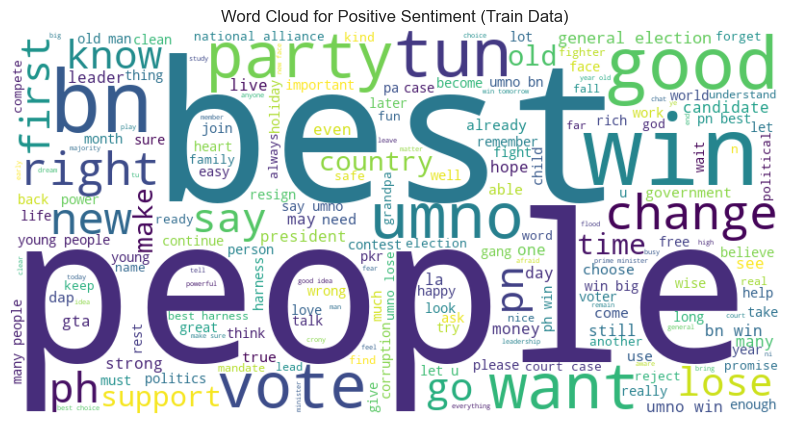

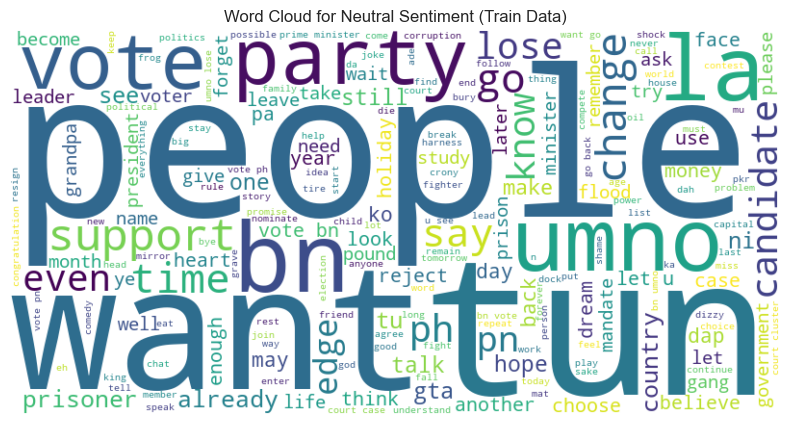

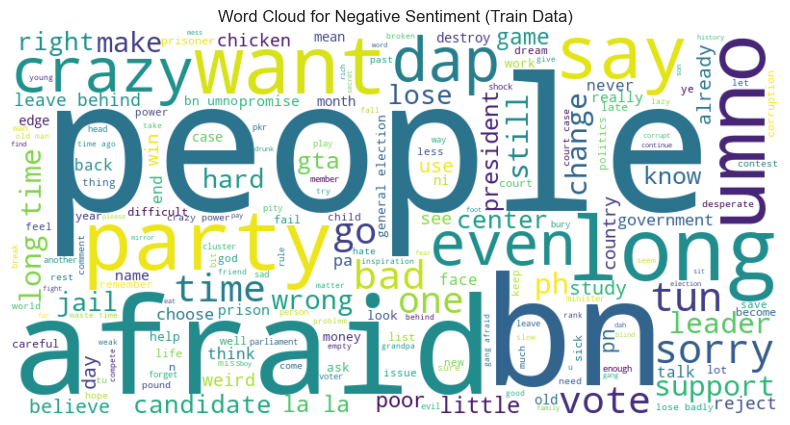

In [50]:
for sentiment in ["Positive", "Neutral", "Negative"]:
    words = train_df[train_df['Sentiment'] == sentiment]['Final_Comment'].apply(preprocess_text).sum()
    generate_wordcloud(words, f"Word Cloud for {sentiment} Sentiment (Train Data)")

# Model training



COMPLEMENT NAIVE BAYES MODEL

✅ ComplementNB Model
Training Accuracy: 88.74%
------------------------------------------------
Training Confusion Matrix:
      0     1     2
0  684    54    86
1  163  3622   344
2   53    99  1991
------------------------------------------------
Training Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.83      0.79       824
           1       0.96      0.88      0.92      4129
           2       0.82      0.93      0.87      2143

    accuracy                           0.89      7096
   macro avg       0.85      0.88      0.86      7096
weighted avg       0.89      0.89      0.89      7096


Test Accuracy: 78.35%
------------------------------------------------
Test Confusion Matrix:
      0    1    2
0  119   26   38
1   81  813  170
2   22   47  458
------------------------------------------------
Test Classification Report:
               precision    recall  f1-score   support

         

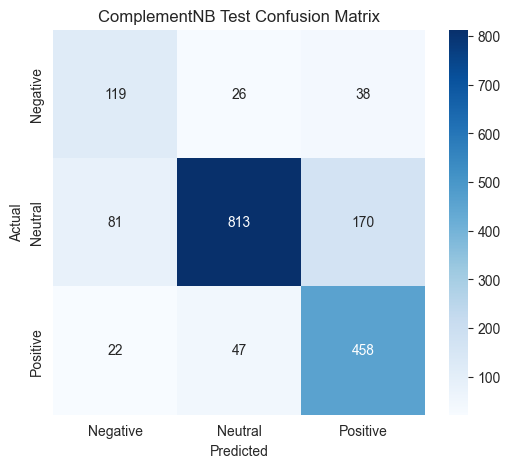


GAUSSIAN NAIVE BAYES MODEL

✅ GaussianNB Model
Training Accuracy: 38.60%
------------------------------------------------
Training Confusion Matrix:
       0    1    2
0   824    0    0
1  2768  968  393
2  1185   11  947
------------------------------------------------
Training Classification Report:
               precision    recall  f1-score   support

           0       0.17      1.00      0.29       824
           1       0.99      0.23      0.38      4129
           2       0.71      0.44      0.54      2143

    accuracy                           0.39      7096
   macro avg       0.62      0.56      0.41      7096
weighted avg       0.81      0.39      0.42      7096


Test Accuracy: 24.75%
------------------------------------------------
Test Confusion Matrix:
      0    1    2
0  130   20   33
1  732  159  173
2  320   57  150
------------------------------------------------
Test Classification Report:
               precision    recall  f1-score   support

           0     

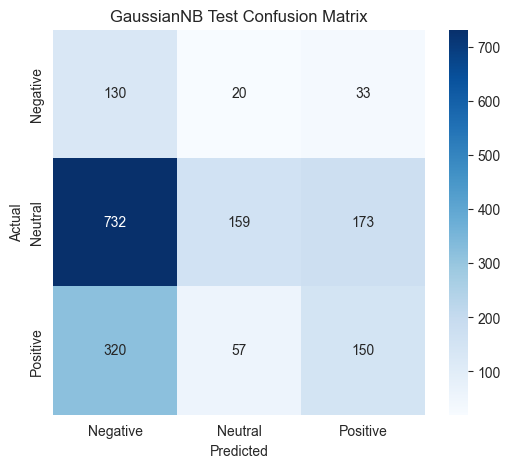


BERNOULLI NAIVE BAYES MODEL

✅ BernoulliNB Model
Training Accuracy: 86.53%
------------------------------------------------
Training Confusion Matrix:
      0     1     2
0  378   347    99
1   62  3949   118
2   23   307  1813
------------------------------------------------
Training Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.46      0.59       824
           1       0.86      0.96      0.90      4129
           2       0.89      0.85      0.87      2143

    accuracy                           0.87      7096
   macro avg       0.86      0.75      0.79      7096
weighted avg       0.86      0.87      0.86      7096


Test Accuracy: 81.96%
------------------------------------------------
Test Confusion Matrix:
     0    1    2
0  58   74   51
1  12  996   56
2  31   96  400
------------------------------------------------
Test Classification Report:
               precision    recall  f1-score   support

           0   

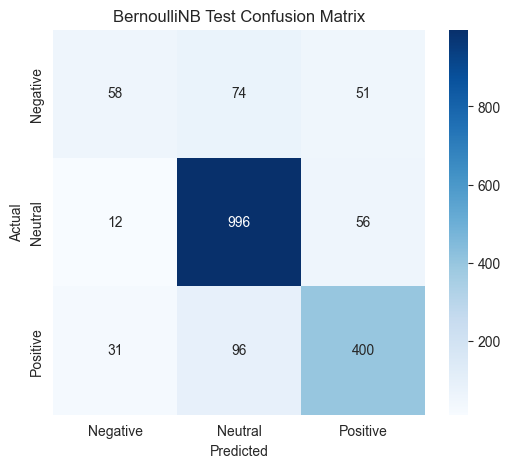

In [51]:
# 1. ComplementNB
print("\n" + "="*80)
print("COMPLEMENT NAIVE BAYES MODEL")
print("="*80)
complement_nb = ComplementNB()
complement_model, train_pred_comp, test_pred_comp = train_evaluate_model(
    "ComplementNB", complement_nb, X_train, y_train, X_test, y_test
)
plot_confusion_matrix(y_test, test_pred_comp, "ComplementNB Test Confusion Matrix")

# 2. GaussianNB
print("\n" + "="*80)
print("GAUSSIAN NAIVE BAYES MODEL")
print("="*80)
gaussian_nb = GaussianNB()

# GaussianNB expects dense arrays, not sparse matrices:
X_train_dense = X_train.toarray()
X_test_dense  = X_test.toarray()

gaussian_model, train_pred_gauss, test_pred_gauss = train_evaluate_model(
    "GaussianNB", 
    gaussian_nb, 
    X_train_dense, 
    y_train, 
    X_test_dense, 
    y_test
)
plot_confusion_matrix(y_test, test_pred_gauss, "GaussianNB Test Confusion Matrix")

# 3. BernoulliNB
print("\n" + "="*80)
print("BERNOULLI NAIVE BAYES MODEL")
print("="*80)
bernoulli_nb = BernoulliNB()
bernoulli_model, train_pred_bern, test_pred_bern = train_evaluate_model(
    "BernoulliNB", bernoulli_nb, X_train, y_train, X_test, y_test
)
plot_confusion_matrix(y_test, test_pred_bern, "BernoulliNB Test Confusion Matrix")

In [52]:
# Pipeline Implementation (ComplementNB as example)
print("\n" + "=" * 80)
print("COMPLEMENTNB PIPELINE IMPLEMENTATION")
print("=" * 80)
pipeline = make_pipeline(TfidfVectorizer(max_features=5000), ComplementNB())
pipeline.fit(X_train_text, y_train)

# Training evaluation
y_train_pred_pipe = pipeline.predict(X_train_text)
print("\nTraining Accuracy:", accuracy_score(y_train, y_train_pred_pipe))

# Test evaluation
y_test_pred_pipe = pipeline.predict(X_test_text)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_pipe))


COMPLEMENTNB PIPELINE IMPLEMENTATION

Training Accuracy: 0.8874013528748591
Test Accuracy: 0.7835400225479143


# Feature importance


C:\Users\amirb\AppData\Local\Temp\ipykernel_12820\2636652948.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(scores), y=list(words), palette='coolwarm')


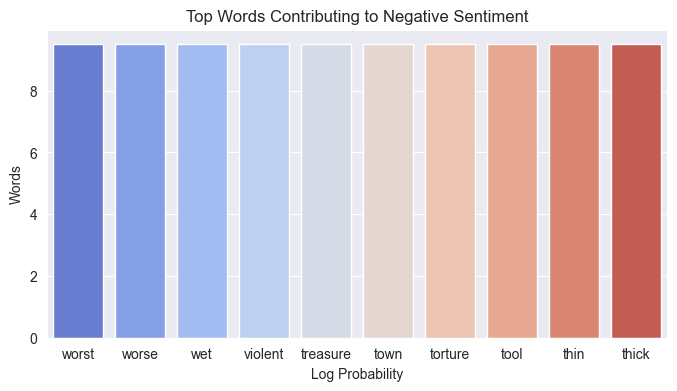

C:\Users\amirb\AppData\Local\Temp\ipykernel_12820\2636652948.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(scores), y=list(words), palette='coolwarm')


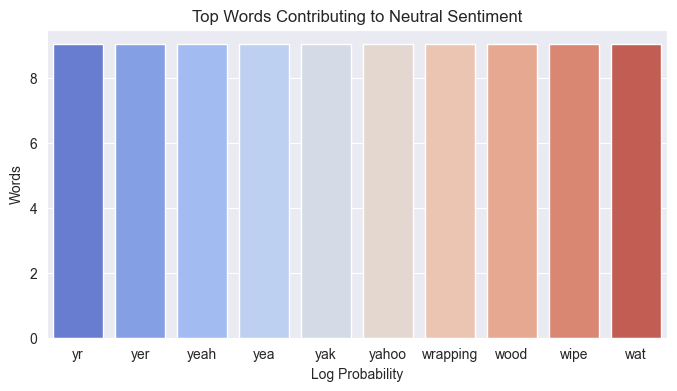

C:\Users\amirb\AppData\Local\Temp\ipykernel_12820\2636652948.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(scores), y=list(words), palette='coolwarm')


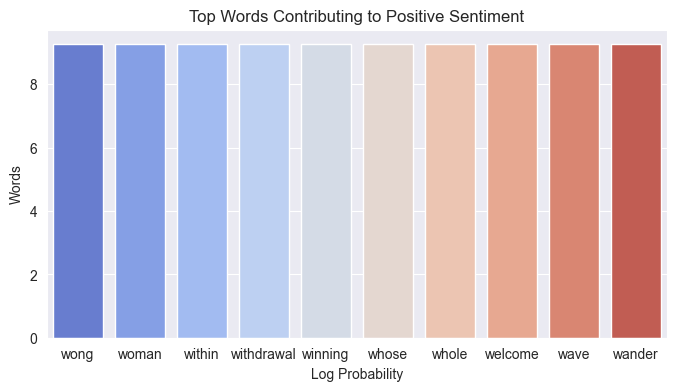

In [53]:
feature_names = pipeline.named_steps['tfidfvectorizer'].get_feature_names_out()
feature_log_probs = pipeline.named_steps['complementnb'].feature_log_prob_

for i, label in enumerate(["Negative", "Neutral", "Positive"]):
    top_features = sorted(zip(feature_log_probs[i], feature_names), reverse=True)[:10]
    words, scores = zip(*top_features)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=list(scores), y=list(words), palette='coolwarm')
    plt.title(f"Top Words Contributing to {label} Sentiment")
    plt.xlabel("Log Probability")
    plt.ylabel("Words")
    plt.show()

# Sentiment distribution


# Save Models
joblib.dump(complement_model, 'complement_nb_model_textblob.pkl')
joblib.dump(multinomial_model, 'multinomial_nb_model_textblob.pkl')
joblib.dump(bernoulli_model, 'bernoulli_nb_model_textblob.pkl')
joblib.dump(pipeline, 'sentiment_pipeline_textblob.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer_textblob.pkl')

In [54]:
# Train the pipeline
pipeline = make_pipeline(
    TfidfVectorizer(max_features=5000),
    BernoulliNB()
)
pipeline.fit(train_df['Final_Comment'], train_df['Sentiment_Label'])

# Save the pipeline
joblib.dump(pipeline, 'bernoulli_nb_model_textblob_baseline.joblib')

['bernoulli_nb_model_textblob_baseline.joblib']

C:\Users\amirb\AppData\Local\Temp\ipykernel_12820\553785280.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Sentiment'], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])


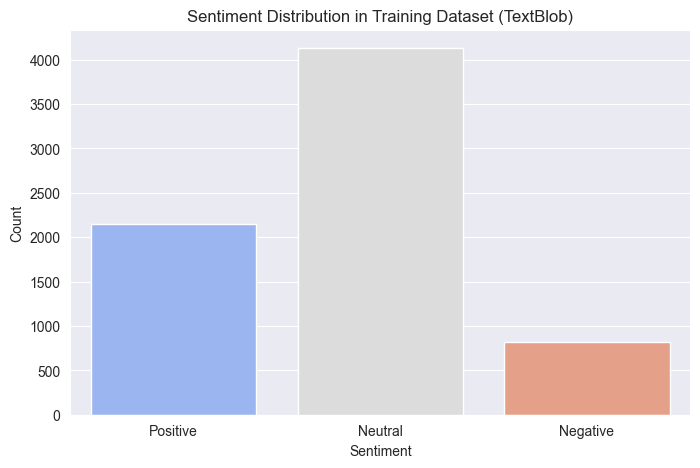

C:\Users\amirb\AppData\Local\Temp\ipykernel_12820\553785280.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Sentiment'], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])


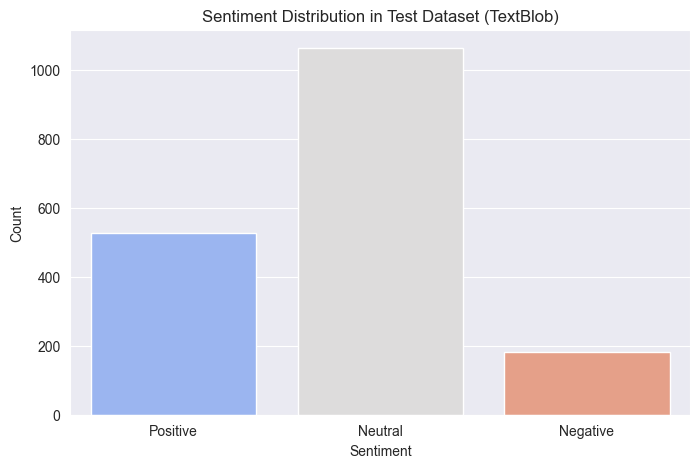

In [55]:
plot_sentiment_distribution(train_df, "Sentiment Distribution in Training Dataset (TextBlob)")
plot_sentiment_distribution(test_df, "Sentiment Distribution in Test Dataset (TextBlob)")

combined_df = pd.concat(
    [
        pd.read_csv('train_textblob_NB.csv'),
        pd.read_csv('test_textblob_NB.csv')
    ],
    ignore_index=True
)
combined_df.to_csv('combined_baseline_nb_textblob.csv', index=False)
print("✅ Combined sentiment dataset saved as 'combined_baseline_nb_textblob.csv'")